In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

packages = [
    'tensorflow',
    'opencv-python-headless',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'numpy',
    'pandas',
    'tqdm',
    'imbalanced-learn'
]

for pkg in packages:
    try:
        install(pkg)
    except Exception as e:
        print(f'Warning: Could not install {pkg}: {e}')

print('All packages installed successfully!')

✅ All packages installed successfully!


In [ ]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import random
import time
import json
from pathlib import Path
from tqdm import tqdm
from collections import Counter

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f' TensorFlow version: {tf.__version__}')
print(f' OpenCV version: {cv2.__version__}')
print(f' GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU Device: {gpus[0].name}')
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass
else:
    print('   Running on CPU — training will be slower but still works!')
print(' All imports successful!')

✅ TensorFlow version: 2.17.0
✅ OpenCV version: 4.10.0
✅ GPU available: False
   Running on CPU — training will be slower but still works!
✅ All imports successful!


In [ ]:
HEALTHY_VIDEO_DIR   = r"C:\Users\vyshnavpradeep\OneDrive\Desktop\healthy video"    
DISEASED_VIDEO_DIR  = r"C:\Users\vyshnavpradeep\OneDrive\Desktop\diseased video"  
OUTPUT_DIR          = r"C:\Users\vyshnavpradeep\OneDrive\Desktop\ev"           

CONFIG = {
    # Video processing
    'IMG_SIZE'        : 224,          
    'NUM_FRAMES'      : 16,           
    'FRAME_SKIP'      : None,         
    'VIDEO_EXTS'      : ('.mp4', '.avi', '.mov', '.mkv', '.wmv', '.flv', '.webm'),

    # Training
    'BATCH_SIZE'      : 4,            
    'EPOCHS_FROZEN'   : 10,           
    'EPOCHS_FINETUNE' : 20,           
    'LR_FROZEN'       : 1e-3,
    'LR_FINETUNE'     : 1e-5,
    'DROPOUT'         : 0.5,
    'L2_REG'          : 1e-4,

    # Cross-validation
    'USE_KFOLD'       : True,         
    'N_FOLDS'         : 5,
    'VAL_SPLIT'       : 0.2,          

    # Augmentation strength (higher = more augmentation)
    'AUGMENT_STRENGTH': 'strong',     

    # Ensemble
    'USE_ENSEMBLE'    : True,         #

    # Paths
    'OUTPUT_DIR'      : OUTPUT_DIR,
    'SEED'            : SEED,
}



errors = []
for label, path in [('HEALTHY_VIDEO_DIR', HEALTHY_VIDEO_DIR), ('DISEASED_VIDEO_DIR', DISEASED_VIDEO_DIR)]:
    if not os.path.exists(path):
        errors.append(f' {label} does not exist: {path}')
    else:
        vids = [f for f in os.listdir(path) if f.lower().endswith(CONFIG['VIDEO_EXTS'])]
        print(f'   {label}: {path}')
        print(f'   Found {len(vids)} video(s): {", ".join(vids[:5])}{" ..." if len(vids)>5 else ""}')

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f' OUTPUT_DIR: {OUTPUT_DIR}')

if errors:
    for e in errors:
        print(e)
    raise FileNotFoundError('Fix the paths above before continuing.')

print('\n Configuration complete!')

✅ HEALTHY_VIDEO_DIR: C:\Users\vyshnavpradeep\OneDrive\Desktop\healthy video
   Found 34 video(s): 122393-725067811_medium.mp4, 207721_medium.mp4, 219124_medium.mp4, 285868_medium.mp4, 79865-570708317_medium.mp4 ...
✅ DISEASED_VIDEO_DIR: C:\Users\vyshnavpradeep\OneDrive\Desktop\diseased video
   Found 29 video(s): 3557808303-preview.mp4, 3557812397-preview.mp4, new.mp4, newww.mp4, Recording 2026-04-08 225406.mp4 ...
✅ OUTPUT_DIR: C:\Users\vyshnavpradeep\OneDrive\Desktop\ev

✅ Configuration complete!


In [ ]:
def extract_frames(video_path, num_frames=CONFIG['NUM_FRAMES'], img_size=CONFIG['IMG_SIZE']):
    """
    Uniformly sample `num_frames` frames from a video.
    Returns numpy array of shape (num_frames, img_size, img_size, 3).
    Returns None if video cannot be read.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f'Cannot open: {video_path}')
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        print(f'Empty video: {video_path}')
        return None

    # Uniform sampling indices
    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)
        else:
            # Fallback: duplicate last good frame
            if frames:
                frames.append(frames[-1].copy())
            else:
                frames.append(np.zeros((img_size, img_size, 3), dtype=np.uint8))

    cap.release()

    # Ensure exactly num_frames
    while len(frames) < num_frames:
        frames.append(frames[-1].copy() if frames else np.zeros((img_size, img_size, 3), dtype=np.uint8))

    frames = np.array(frames[:num_frames], dtype=np.float32) / 255.0
    return frames  # (T, H, W, 3)


def get_video_info(video_path):
    """Return basic info dict about a video file."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None
    info = {
        'path'     : str(video_path),
        'frames'   : int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        'fps'      : cap.get(cv2.CAP_PROP_FPS),
        'width'    : int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height'   : int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    info['duration_sec'] = round(info['frames'] / info['fps'], 2) if info['fps'] > 0 else 0
    cap.release()
    return info


print('Frame extraction utilities defined.')

✅ Frame extraction utilities defined.


Scanning video directories...
  HEALTHY   : 34 videos found in C:\Users\vyshnavpradeep\OneDrive\Desktop\healthy video
  DISEASED  : 29 videos found in C:\Users\vyshnavpradeep\OneDrive\Desktop\diseased video

Total videos: 63
label_name
diseased    29
healthy     34

📋 Sample video info:
  [healthy] 2560x1440 @ 30.0fps | 458 frames | 15.28s
  [diseased] 898x506 @ 30.0fps | 790 frames | 26.36s


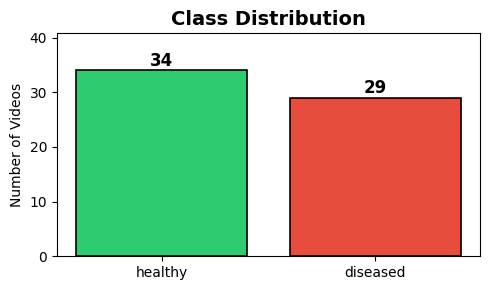


✅ Dataset loaded successfully!


In [ ]:
def load_video_paths(healthy_dir, diseased_dir, extensions):
    """
    Scan directories and return lists of (path, label) tuples.
    label: 0 = healthy, 1 = diseased
    """
    records = []
    for label, folder in [(0, healthy_dir), (1, diseased_dir)]:
        label_name = 'healthy' if label == 0 else 'diseased'
        folder = Path(folder)
        vids = sorted([p for p in folder.iterdir() if p.suffix.lower() in extensions])
        print(f'  {label_name.upper():10s}: {len(vids)} videos found in {folder}')
        for v in vids:
            records.append({'path': str(v), 'label': label, 'label_name': label_name, 'filename': v.name})
    return pd.DataFrame(records)


print('Scanning video directories...')
df = load_video_paths(HEALTHY_VIDEO_DIR, DISEASED_VIDEO_DIR, set(CONFIG['VIDEO_EXTS']))

print(f'\nTotal videos: {len(df)}')
print(df.groupby('label_name').size().to_string())

# Quick dataset check
if len(df) < 4:
    raise ValueError(' Too few videos (need at least 4). Add more videos and re-run.')

# Show video info for first video of each class
print('\n Sample video info:')
for _, row in df.groupby('label').first().iterrows():
    info = get_video_info(row['path'])
    if info:
        print(f"  [{row['label_name']}] {info['width']}x{info['height']} @ {info['fps']:.1f}fps | "
              f"{info['frames']} frames | {info['duration_sec']}s")

# Visualize class distribution
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
counts = df['label_name'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Videos')
ax.set_ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print('\n Dataset loaded successfully!')

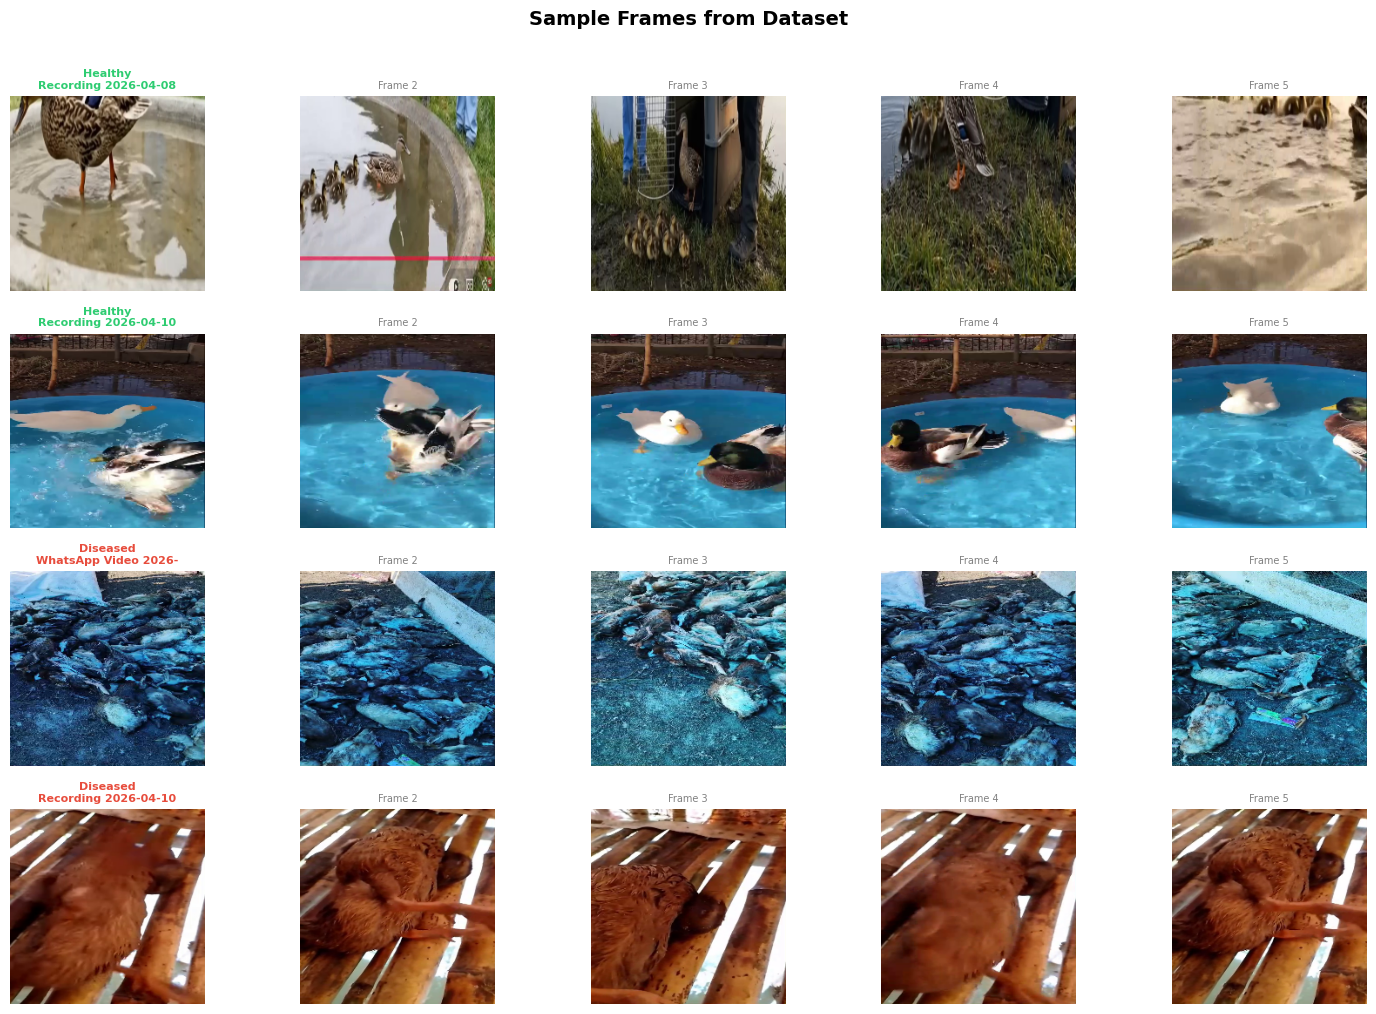

✅ Frame preview saved.


In [ ]:
def preview_video_frames(df, num_samples=2, frames_to_show=5):
    """Visualize sample frames from healthy and diseased videos."""
    fig, axes = plt.subplots(
        num_samples * 2, frames_to_show,
        figsize=(frames_to_show * 3, num_samples * 2 * 2.5)
    )
    if axes.ndim == 1:
        axes = axes[np.newaxis, :]

    row_idx = 0
    for label in [0, 1]:
        label_name = 'Healthy' if label == 0 else 'Diseased'
        color = '#2ecc71' if label == 0 else '#e74c3c'
        subset = df[df['label'] == label].sample(min(num_samples, len(df[df['label']==label])), random_state=SEED)

        for _, row in subset.iterrows():
            frames = extract_frames(row['path'], num_frames=frames_to_show)
            if frames is None:
                continue
            for col_idx, frame in enumerate(frames[:frames_to_show]):
                ax = axes[row_idx, col_idx]
                ax.imshow(frame)
                ax.axis('off')
                if col_idx == 0:
                    ax.set_title(f'{label_name}\n{row["filename"][:20]}',
                                 color=color, fontsize=8, fontweight='bold')
                else:
                    ax.set_title(f'Frame {col_idx+1}', fontsize=7, color='gray')
            row_idx += 1

    plt.suptitle('Sample Frames from Dataset', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_frames.png'), dpi=120, bbox_inches='tight')
    plt.show()

try:
    preview_video_frames(df, num_samples=min(2, len(df)//2), frames_to_show=5)
    print('Frame preview saved.')
except Exception as e:
    print(f'Preview skipped: {e}')

In [ ]:
print('Building EfficientNetB0 feature extractor (pre-trained on ImageNet)...')

# Build feature extractor — frozen EfficientNetB0
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'], 3),
    pooling='avg'   # Global average pooling 
)
base_model.trainable = False
feature_extractor = base_model

print(f'Feature extractor output shape: {base_model.output_shape}')  # (None, 1280)
print(f'Total params: {base_model.count_params():,}')


def extract_video_features(video_path, extractor, num_frames=CONFIG['NUM_FRAMES']):
    """
    Extract CNN features for each frame → returns shape (num_frames, feature_dim).
    """
    frames = extract_frames(video_path, num_frames=num_frames)
    if frames is None:
        return None
    # EfficientNet expects pixel values 0-255 (it includes own preprocessing)
    frames_uint = (frames * 255.0).astype(np.float32)
    features = extractor.predict(frames_uint, verbose=0)  # (T, 1280)
    return features


print('Feature extractor ready!')
print('\nNext: extracting features from all videos (this may take a few minutes)...')

Building EfficientNetB0 feature extractor (pre-trained on ImageNet)...
Feature extractor output shape: (None, 1280)
Total params: 4,049,571
✅ Feature extractor ready!

Next: extracting features from all videos (this may take a few minutes)...


In [ ]:
FEATURE_CACHE = os.path.join(OUTPUT_DIR, 'features_cache.npz')

def build_feature_dataset(df, extractor, cache_path, num_frames=CONFIG['NUM_FRAMES']):
    """
    Extract features for all videos. Caches to disk to avoid re-extraction.
    Returns X: (N, T, 1280), y: (N,)
    """
    if os.path.exists(cache_path):
        print(f'Loading cached features from: {cache_path}')
        data = np.load(cache_path, allow_pickle=True)
        X, y = data['X'], data['y']
        print(f'   X shape: {X.shape}, y shape: {y.shape}')
        return X, y

    print(f'Extracting features for {len(df)} videos...')
    X_list, y_list, valid_idx = [], [], []

    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc='Extracting')):
        feats = extract_video_features(row['path'], extractor, num_frames)
        if feats is not None and feats.shape == (num_frames, 1280):
            X_list.append(feats)
            y_list.append(row['label'])
            valid_idx.append(i)
        else:
            print(f'Skipping {row["filename"]} — could not extract features.')

    X = np.array(X_list, dtype=np.float32)  # (N, T, 1280)
    y = np.array(y_list, dtype=np.int32)    # (N,)

    np.savez_compressed(cache_path, X=X, y=y)
    print(f'   Features saved to cache: {cache_path}')
    print(f'   X shape: {X.shape}, y shape: {y.shape}')
    return X, y


X, y = build_feature_dataset(df, feature_extractor, FEATURE_CACHE)

# Class distribution after extraction
class_counts = Counter(y)
print(f'\nClass counts after extraction:')
print(f'  Healthy  (0): {class_counts[0]}')
print(f'  Diseased (1): {class_counts[1]}')

if len(X) < 4:
    raise ValueError('❌ Need at least 4 valid videos to train. Check your video files.')

print('\n Feature extraction complete!')

📂 Loading cached features from: C:\Users\vyshnavpradeep\OneDrive\Desktop\ev\features_cache.npz
   X shape: (63, 16, 1280), y shape: (63,)

Class counts after extraction:
  Healthy  (0): 34
  Diseased (1): 29

✅ Feature extraction complete!


In [ ]:
def augment_sequence(X_seq, strength='strong'):
    """
    Augment a feature sequence (T, D) in feature space.
    Simulates temporal jitter, noise, and scaling.
    """
    T, D = X_seq.shape
    aug = X_seq.copy()

    if strength in ('moderate', 'strong'):
        # Gaussian noise injection
        noise_std = 0.02 if strength == 'moderate' else 0.05
        aug += np.random.normal(0, noise_std, aug.shape).astype(np.float32)

        # Random temporal reversal (25% chance)
        if np.random.rand() < 0.25:
            aug = aug[::-1].copy()

        # Random frame dropout (replace with neighbor)
        drop_prob = 0.05 if strength == 'moderate' else 0.1
        for t in range(1, T - 1):
            if np.random.rand() < drop_prob:
                aug[t] = (aug[t-1] + aug[t+1]) / 2.0

    if strength == 'strong':
        # Feature scaling
        scale = np.random.uniform(0.9, 1.1)
        aug *= scale

        # Temporal shift (circular)
        shift = np.random.randint(-2, 3)
        aug = np.roll(aug, shift, axis=0)

    # Clip to reasonable range
    aug = np.clip(aug, 0, None)
    return aug


def oversample_minority(X, y, target_ratio=1.0, strength='strong', random_state=SEED):
    """
    Augmentation-based oversampling of minority class.
    Creates synthetic samples by augmenting existing ones.
    """
    np.random.seed(random_state)
    counts = Counter(y)
    majority_class = max(counts, key=counts.get)
    minority_class = min(counts, key=counts.get)
    n_majority = counts[majority_class]
    n_minority = counts[minority_class]
    n_needed   = int(n_majority * target_ratio) - n_minority

    if n_needed <= 0:
        print('  Classes already balanced — no oversampling needed.')
        return X, y

    print(f'Oversampling minority class (class {minority_class}): {n_minority} → {n_minority + n_needed}')
    minority_X = X[y == minority_class]
    new_samples = []

    for i in range(n_needed):
        src = minority_X[i % len(minority_X)]
        aug = augment_sequence(src, strength=strength)
        new_samples.append(aug)

    X_aug = np.concatenate([X, np.array(new_samples, dtype=np.float32)], axis=0)
    y_aug = np.concatenate([y, np.full(n_needed, minority_class, dtype=np.int32)], axis=0)

    # Shuffle
    idx = np.random.permutation(len(X_aug))
    return X_aug[idx], y_aug[idx]


print(' Augmentation functions defined.')
print(f'   Augmentation strength: {CONFIG["AUGMENT_STRENGTH"]}')

✅ Augmentation functions defined.
   Augmentation strength: strong


In [ ]:
class TemporalAttentionPool(keras.layers.Layer):
    """
    Weighted sum over the time axis.
    Input : (batch, T, D) — attention-weighted LSTM outputs
    Output: (batch, D)    — single context vector
    """
    def call(self, x):
        return tf.reduce_sum(x, axis=1)

    def get_config(self):
        return super().get_config()


def build_model(input_shape, dropout=CONFIG['DROPOUT'], l2_reg=CONFIG['L2_REG']):
    """
    Temporal classifier:
      Input: (T, feature_dim) pre-extracted CNN features
      Architecture: LayerNorm → BiLSTM → Attention → Dense → Output
    """
    inputs = keras.Input(shape=input_shape, name='frame_features')  # (T, 1280)

    # Normalize features
    x = layers.LayerNormalization()(inputs)

    # Bidirectional LSTM for temporal context
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3,
                    kernel_regularizer=regularizers.l2(l2_reg))
    )(x)  # (T, 256)

    # Self-attention: focus on most diagnostic frames
    attn_scores = layers.Dense(1, activation='softmax', name='frame_attention')(x)  # (T, 1)
    x = layers.Multiply()([x, attn_scores])          # element-wise weighting
    x = TemporalAttentionPool(name='temporal_pool')(x)  # (256,)  ← no Lambda!

    # Classifier head
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout / 2)(x)

    # Binary output
    outputs = layers.Dense(1, activation='sigmoid', name='prediction')(x)

    model = keras.Model(inputs, outputs, name='DuckHealthClassifier')
    return model


# Test model build
input_shape = (CONFIG['NUM_FRAMES'], 1280)
_test_model = build_model(input_shape)
_test_model.summary()
del _test_model

print('\n Model architecture defined (no Lambda layers — safe to load in production)!')

Model: "DuckHealthClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frame_features      │ (None, 16, 1280)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 1280)  │      2,560 │ frame_features[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 16, 256)   │  1,442,816 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frame_attention     │ (None, 16, 1)     │        257 │ bidirectional[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 256)   │          0 │ bidirectional[0]… │
│                     │                   │            │ frame_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_pool       │ (None, 256)       │          0 │ multiply[0][0]    │
│ (TemporalAttention… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ temporal_pool[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,487,362 (5.67 MB)

 Trainable params: 1,487,106 (5.67 MB)

 Non-trainable params: 256 (1.00 KB)


✅ Model architecture defined (no Lambda layers — safe to load in production)!


In [ ]:
def get_callbacks(model_save_path, monitor='val_loss', patience_es=10, patience_rl=5):
    """Return a list of training callbacks."""
    cb = [
        callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor=monitor,
            save_best_only=True,
            mode='min' if 'loss' in monitor else 'max',
            verbose=0
        ),
        callbacks.EarlyStopping(
            monitor=monitor,
            patience=patience_es,
            restore_best_weights=True,
            verbose=1,
            mode='min' if 'loss' in monitor else 'max'
        ),
        callbacks.ReduceLROnPlateau(
            monitor=monitor,
            factor=0.5,
            patience=patience_rl,
            min_lr=1e-7,
            verbose=0
        ),
    ]
    return cb


def compute_class_weights(y):
    """Compute balanced class weights to handle imbalanced datasets."""
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes.tolist(), weights.tolist()))


print(' Callbacks defined.')

✅ Callbacks defined.


In [ ]:
input_shape = (CONFIG['NUM_FRAMES'], 1280)
fold_results = []
fold_histories = []
fold_models_paths = []

n_folds = CONFIG['N_FOLDS']
# Reduce folds if dataset is very small
min_class = min(Counter(y).values())
n_folds = min(n_folds, min_class)
if n_folds < 2:
    print(f'  Only {min_class} sample(s) in minority class. Switching to simple train/val split.')
    CONFIG['USE_KFOLD'] = False
else:
    print(f'Using {n_folds}-Fold Stratified Cross-Validation')

if CONFIG['USE_KFOLD']:
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    splits = list(skf.split(X, y))
else:
    # Simple train/val split
    tr_idx, va_idx = train_test_split(
        np.arange(len(X)), test_size=CONFIG['VAL_SPLIT'], stratify=y, random_state=SEED
    )
    splits = [(tr_idx, va_idx)]


for fold, (train_idx, val_idx) in enumerate(splits):
    fold_label = f'Fold {fold+1}/{len(splits)}'
    print(f'\n{"="*50}')
    print(f'  {fold_label}')
    print(f'{"="*50}')

    X_tr, y_tr = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Augmentation-based oversampling on training set only
    X_tr_aug, y_tr_aug = oversample_minority(X_tr, y_tr, strength=CONFIG['AUGMENT_STRENGTH'])
    print(f'  Train: {Counter(y_tr)} → after augmentation: {Counter(y_tr_aug)}')
    print(f'  Val  : {Counter(y_val)}')

    class_weights = compute_class_weights(y_tr_aug)
    print(f'  Class weights: {class_weights}')

    # Model for this fold
    model = build_model(input_shape)
    model.compile(
        optimizer=optimizers.Adam(CONFIG['LR_FROZEN']),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    model_path = os.path.join(OUTPUT_DIR, f'model_fold{fold+1}.keras')
    fold_models_paths.append(model_path)

    cb_list = get_callbacks(model_path, monitor='val_auc', patience_es=12, patience_rl=5)

    # Phase 1: Train classifier head
    print(f'  Phase 1: Training classifier head ({CONFIG["EPOCHS_FROZEN"]} epochs max)')
    hist1 = model.fit(
        X_tr_aug, y_tr_aug,
        validation_data=(X_val, y_val),
        epochs=CONFIG['EPOCHS_FROZEN'],
        batch_size=CONFIG['BATCH_SIZE'],
        class_weight=class_weights,
        callbacks=cb_list,
        verbose=1
    )

    # Load best weights and fine-tune with lower LR
    if os.path.exists(model_path):
        model.load_weights(model_path)

    model.compile(
        optimizer=optimizers.Adam(CONFIG['LR_FINETUNE']),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    print(f'  Phase 2: Fine-tuning ({CONFIG["EPOCHS_FINETUNE"]} epochs max)')
    hist2 = model.fit(
        X_tr_aug, y_tr_aug,
        validation_data=(X_val, y_val),
        epochs=CONFIG['EPOCHS_FINETUNE'],
        batch_size=CONFIG['BATCH_SIZE'],
        class_weight=class_weights,
        callbacks=cb_list,
        verbose=1
    )

    # Load best model and evaluate
    if os.path.exists(model_path):
        model.load_weights(model_path)

    y_pred_prob = model.predict(X_val, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    fold_acc  = accuracy_score(y_val, y_pred)
    fold_auc  = roc_auc_score(y_val, y_pred_prob) if len(np.unique(y_val)) > 1 else 0.5
    fold_f1   = f1_score(y_val, y_pred, zero_division=0)
    fold_prec = precision_score(y_val, y_pred, zero_division=0)
    fold_rec  = recall_score(y_val, y_pred, zero_division=0)

    fold_results.append({
        'fold': fold + 1,
        'accuracy': fold_acc,
        'auc': fold_auc,
        'f1': fold_f1,
        'precision': fold_prec,
        'recall': fold_rec
    })

    hist_combined = {
        k: (hist1.history.get(k, []) + hist2.history.get(k, []))
        for k in set(list(hist1.history.keys()) + list(hist2.history.keys()))
    }
    fold_histories.append(hist_combined)

    print(f'\n  {fold_label} Results:')
    print(f'    Accuracy : {fold_acc:.4f}')
    print(f'    AUC      : {fold_auc:.4f}')
    print(f'    F1-Score : {fold_f1:.4f}')
    print(f'    Precision: {fold_prec:.4f}')
    print(f'    Recall   : {fold_rec:.4f}')

    tf.keras.backend.clear_session()

print('\n' + '='*50)
print(' All folds trained!')
results_df = pd.DataFrame(fold_results)
print('\n Cross-Validation Summary:')
print(results_df.to_string(index=False))
print(f'\n  Mean Accuracy : {results_df["accuracy"].mean():.4f} ± {results_df["accuracy"].std():.4f}')
print(f'  Mean AUC      : {results_df["auc"].mean():.4f} ± {results_df["auc"].std():.4f}')
print(f'  Mean F1       : {results_df["f1"].mean():.4f} ± {results_df["f1"].std():.4f}')

Using 5-Fold Stratified Cross-Validation

  Fold 1/5
Oversampling minority class (class 1): 23 → 27
  Train: Counter({0: 27, 1: 23}) → after augmentation: Counter({0: 27, 1: 27})
  Val  : Counter({0: 7, 1: 6})
  Class weights: {0: 1.0, 1: 1.0}
  Phase 1: Training classifier head (10 epochs max)
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.4757 - auc: 0.4446 - loss: 1.1141 - val_accuracy: 0.6923 - val_auc: 0.7857 - val_loss: 1.1024 - learning_rate: 0.0010
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8153 - auc: 0.8625 - loss: 0.6665 - val_accuracy: 0.8462 - val_auc: 0.7381 - val_loss: 1.2425 - learning_rate: 0.0010
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6838 - auc: 0.8583 - loss: 0.6260 - val_accuracy: 0.7692 - val_auc: 0.7143 - val_loss: 1.5492 - learning_rate: 0.0010
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8552 - auc: 0.9047 - loss: 0.5801 - val_accuracy: 0.7692 - val_auc: 0.7738 - val_loss: 1.1

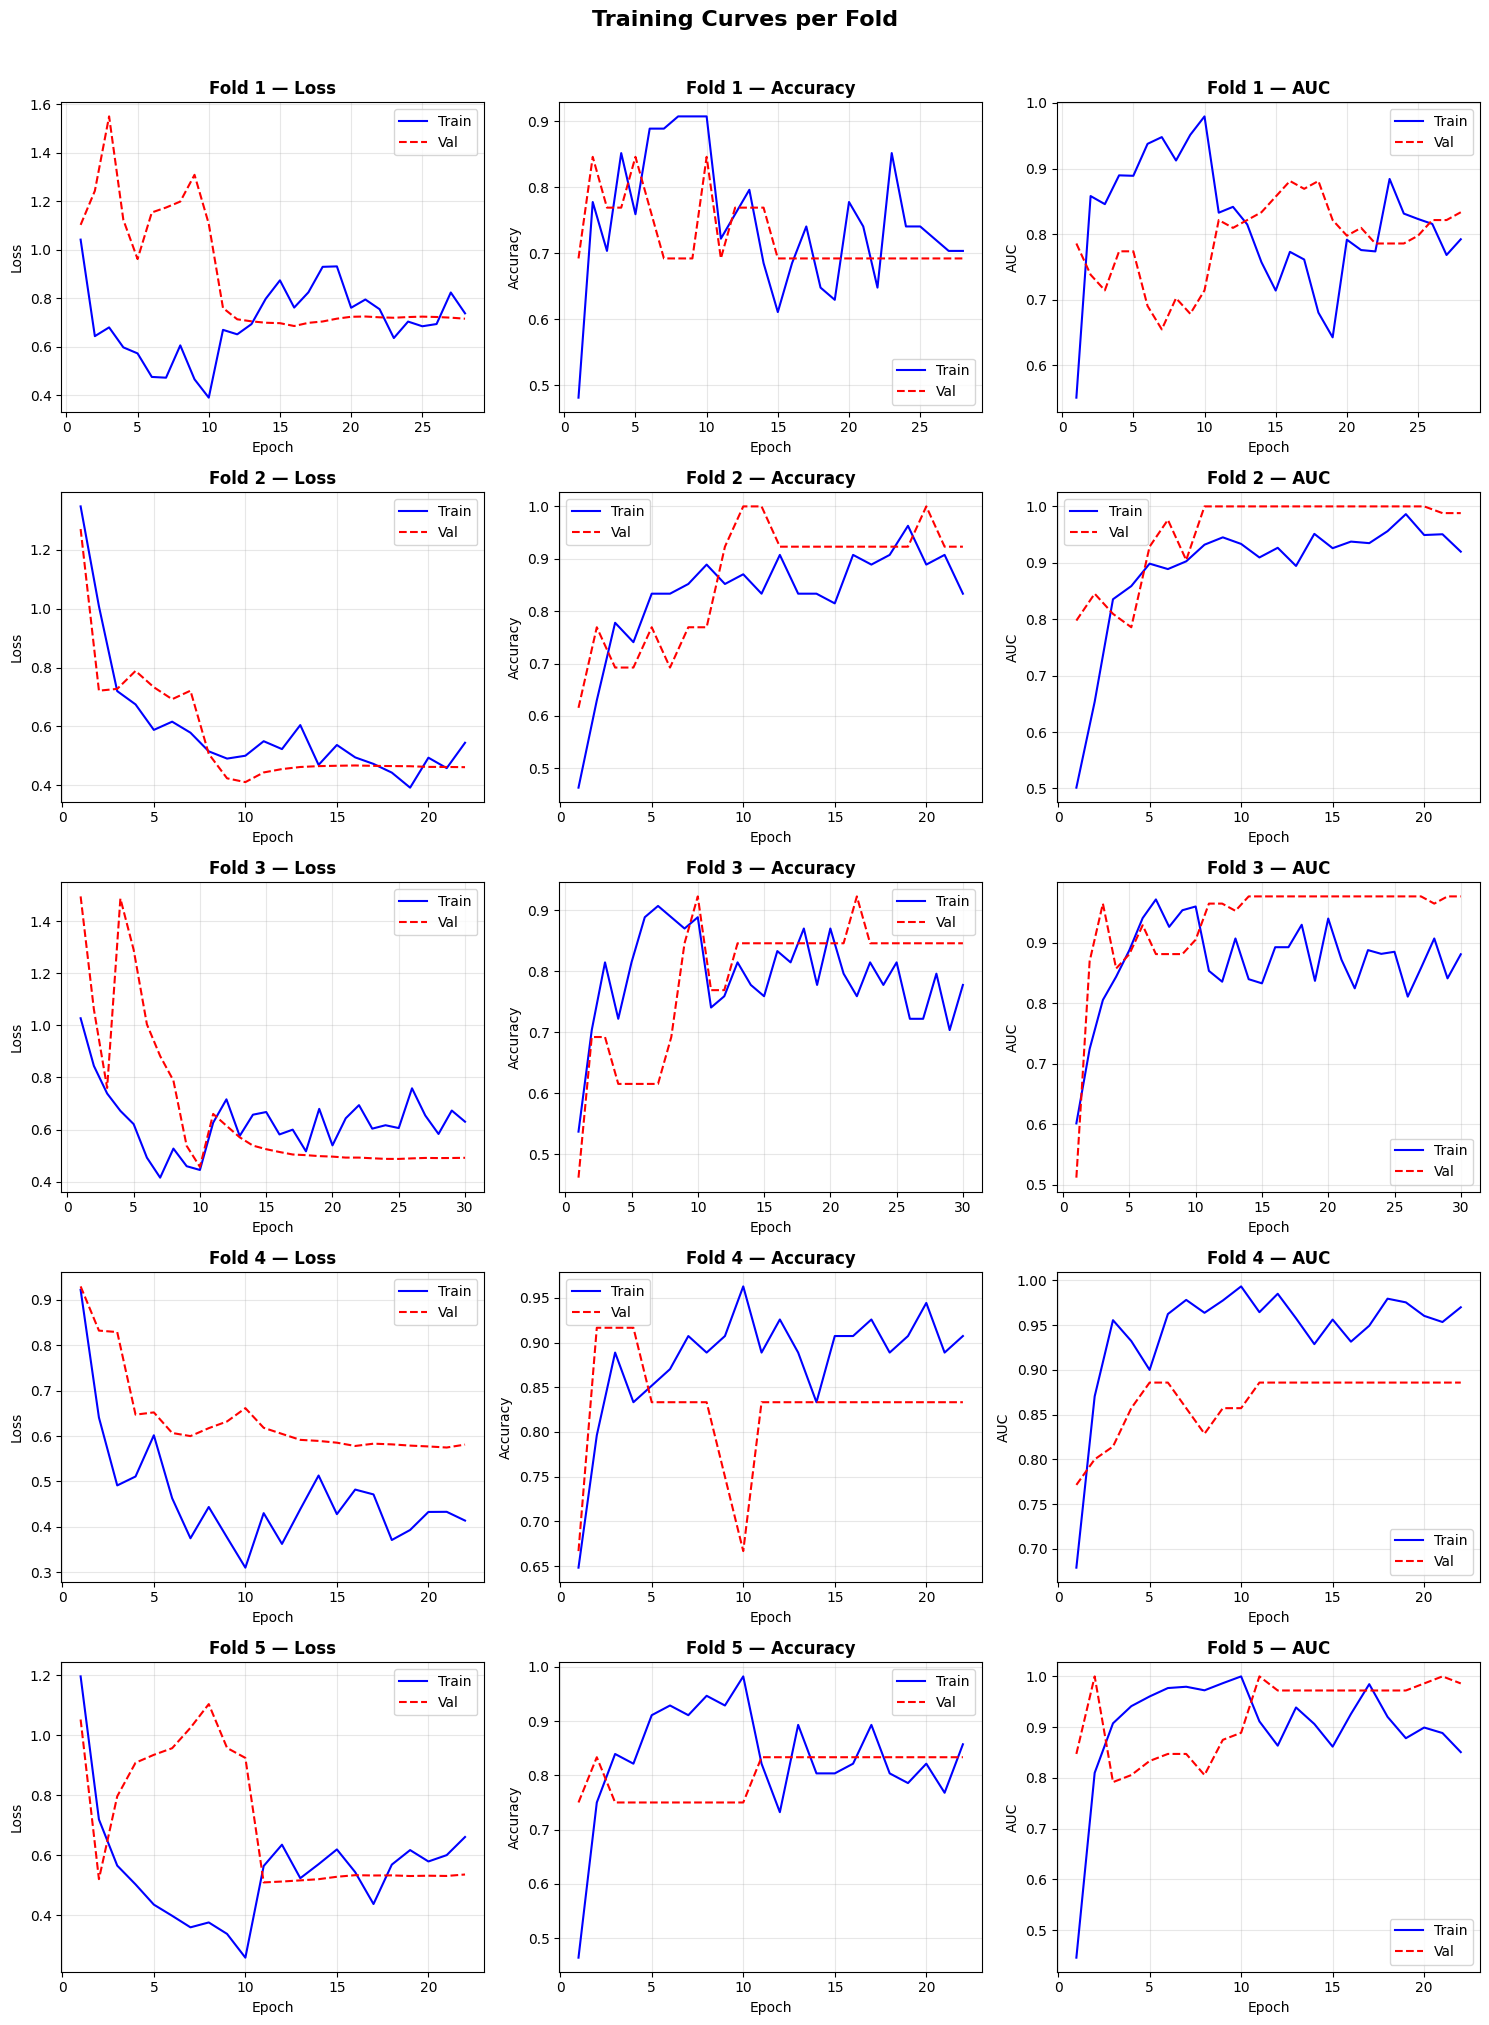

✅ Training curves saved: C:\Users\vyshnavpradeep\OneDrive\Desktop\ev\training_curves.png


In [ ]:
def plot_training_curves(fold_histories, output_dir):
    n_folds = len(fold_histories)
    fig, axes = plt.subplots(n_folds, 3, figsize=(15, 4 * n_folds))
    if n_folds == 1:
        axes = axes[np.newaxis, :]

    for i, hist in enumerate(fold_histories):
        fold_label = f'Fold {i+1}'
        epochs = range(1, len(hist.get('loss', [])) + 1)

        # Loss
        ax = axes[i, 0]
        ax.plot(epochs, hist.get('loss', []), 'b-', label='Train')
        ax.plot(epochs, hist.get('val_loss', []), 'r--', label='Val')
        ax.set_title(f'{fold_label} — Loss', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(); ax.grid(alpha=0.3)

        # Accuracy
        ax = axes[i, 1]
        ax.plot(epochs, hist.get('accuracy', []), 'b-', label='Train')
        ax.plot(epochs, hist.get('val_accuracy', []), 'r--', label='Val')
        ax.set_title(f'{fold_label} — Accuracy', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
        ax.legend(); ax.grid(alpha=0.3)

        # AUC
        ax = axes[i, 2]
        ax.plot(epochs, hist.get('auc', []), 'b-', label='Train')
        ax.plot(epochs, hist.get('val_auc', []), 'r--', label='Val')
        ax.set_title(f'{fold_label} — AUC', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('AUC')
        ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('Training Curves per Fold', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    path = os.path.join(output_dir, 'training_curves.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f' Training curves saved: {path}')


plot_training_curves(fold_histories, OUTPUT_DIR)

Building ensemble from all fold models...
Ensemble from 5 fold model(s)

📊 Ensemble (Full Dataset) Metrics:
  Accuracy : 0.9841
  AUC-ROC  : 1.0000
  F1-Score : 0.9825
  Precision: 1.0000
  Recall   : 0.9655

              precision    recall  f1-score   support

     Healthy       0.97      1.00      0.99        34
    Diseased       1.00      0.97      0.98        29

    accuracy                           0.98        63
   macro avg       0.99      0.98      0.98        63
weighted avg       0.98      0.98      0.98        63



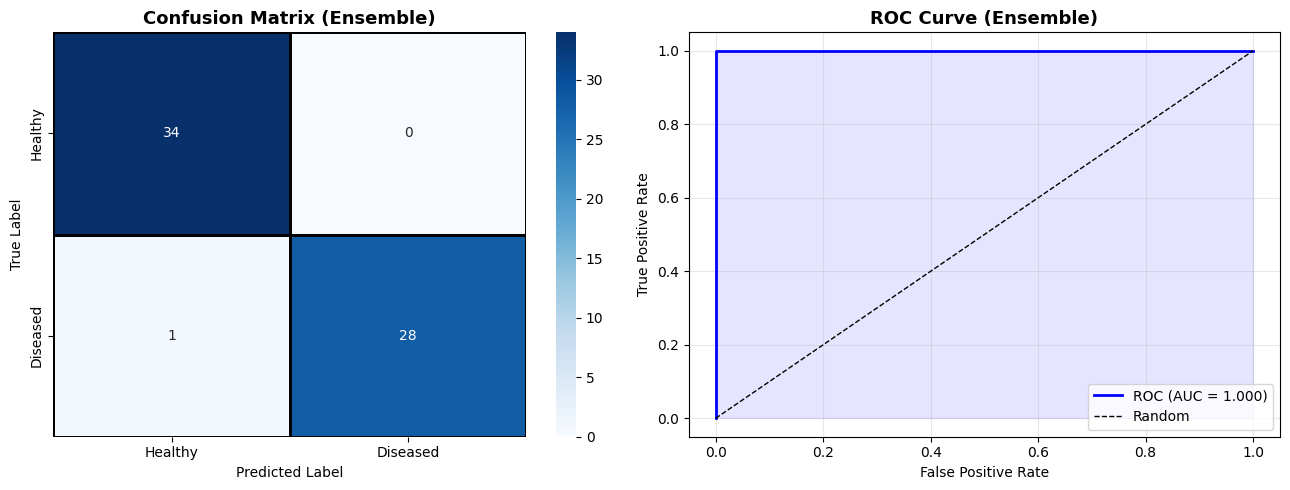

✅ Evaluation plots saved.


In [ ]:
# --- Ensemble: average predictions from all fold models ---
print('Building ensemble from all fold models...')

# Collect all predictions on full dataset
ensemble_preds = np.zeros(len(X), dtype=np.float32)
loaded_count = 0

for fold_idx, model_path in enumerate(fold_models_paths):
    if not os.path.exists(model_path):
        print(f'Model not found: {model_path}')
        continue

    model = build_model(input_shape)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    model.load_weights(model_path)

    preds = model.predict(X, verbose=0).flatten()
    ensemble_preds += preds
    loaded_count += 1

    tf.keras.backend.clear_session()

ensemble_preds /= max(loaded_count, 1)
y_pred_ensemble = (ensemble_preds >= 0.5).astype(int)

print(f'Ensemble from {loaded_count} fold model(s)')

# --- Full dataset metrics ---
acc  = accuracy_score(y, y_pred_ensemble)
auc  = roc_auc_score(y, ensemble_preds) if len(np.unique(y)) > 1 else 0.5
f1   = f1_score(y, y_pred_ensemble, zero_division=0)
prec = precision_score(y, y_pred_ensemble, zero_division=0)
rec  = recall_score(y, y_pred_ensemble, zero_division=0)

print(f'\n Ensemble (Full Dataset) Metrics:')
print(f'  Accuracy : {acc:.4f}')
print(f'  AUC-ROC  : {auc:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall   : {rec:.4f}')
print()
print(classification_report(y, y_pred_ensemble, target_names=['Healthy', 'Diseased']))

# --- Confusion Matrix ---
cm = confusion_matrix(y, y_pred_ensemble)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy', 'Diseased'],
            yticklabels=['Healthy', 'Diseased'],
            linewidths=1, linecolor='black')
axes[0].set_title('Confusion Matrix (Ensemble)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# ROC Curve
if len(np.unique(y)) > 1:
    fpr, tpr, _ = roc_curve(y, ensemble_preds)
    axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc:.3f})')
    axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
    axes[1].set_title('ROC Curve (Ensemble)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'ROC not available\n(single class in data)',
                ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('ROC Curve', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_roc.png'), dpi=150)
plt.show()
print('Evaluation plots saved.')

In [ ]:
# Identify and save the best fold model
best_fold_idx = results_df['auc'].idxmax()
best_fold_num = results_df.loc[best_fold_idx, 'fold']
best_model_src = os.path.join(OUTPUT_DIR, f'model_fold{int(best_fold_num)}.keras')
best_model_dst = os.path.join(OUTPUT_DIR, 'best_model.keras')

import shutil
if os.path.exists(best_model_src):
    shutil.copy2(best_model_src, best_model_dst)
    print(f'   Best model (Fold {int(best_fold_num)}) saved to: {best_model_dst}')
    print(f'   AUC: {results_df.loc[best_fold_idx, "auc"]:.4f}')
    print(f'   Accuracy: {results_df.loc[best_fold_idx, "accuracy"]:.4f}')
else:
    print(f'  Could not find best model: {best_model_src}')

# Save training metadata
metadata = {
    'config': CONFIG,
    'num_samples': int(len(X)),
    'class_counts': {str(k): int(v) for k, v in Counter(y).items()},
    'cross_val_results': fold_results,
    'mean_accuracy': float(results_df['accuracy'].mean()),
    'mean_auc': float(results_df['auc'].mean()),
    'mean_f1': float(results_df['f1'].mean()),
    'best_fold': int(best_fold_num),
    'input_shape': list(input_shape),
}
meta_path = os.path.join(OUTPUT_DIR, 'training_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f' Training metadata saved: {meta_path}')

✅ Best model (Fold 2) saved to: C:\Users\vyshnavpradeep\OneDrive\Desktop\ev\best_model.keras
   AUC: 1.0000
   Accuracy: 0.9231
✅ Training metadata saved: C:\Users\vyshnavpradeep\OneDrive\Desktop\ev\training_metadata.json


📹 Analyzing: Screen Recording 2026-05-16 155447.mp4

🟢 Prediction  : HEALTHY
   Confidence  : 99.3%
   P(Healthy)  : 99.3%
   P(Diseased) : 0.7%


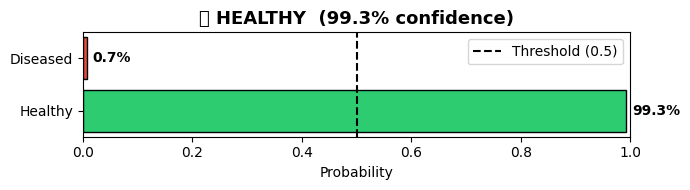

In [ ]:
def predict_video(video_path, model_path=None, threshold=0.5):
    """
    Predict whether a duck in a video is Healthy or Diseased.

    Parameters
    ----------
    video_path : str
        Path to the video file.
    model_path : str, optional
        Path to a saved .keras model. Defaults to best_model.keras in OUTPUT_DIR.
    threshold : float
        Decision threshold (default 0.5).

    Returns
    -------
    dict with keys: label, confidence, healthy_prob, diseased_prob
    """
    if model_path is None:
        model_path = os.path.join(OUTPUT_DIR, 'best_model.keras')

    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Model not found: {model_path}')
    if not os.path.exists(video_path):
        raise FileNotFoundError(f'Video not found: {video_path}')

    print(f' Analyzing: {os.path.basename(video_path)}')

    # Load model
    model = build_model(input_shape)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.load_weights(model_path)

    # Extract features
    features = extract_video_features(video_path, feature_extractor)
    if features is None:
        raise ValueError('Could not extract features from video. Check the file.')

    features_input = features[np.newaxis, ...]  # (1, T, 1280)
    prob_diseased = float(model.predict(features_input, verbose=0)[0, 0])
    prob_healthy  = 1.0 - prob_diseased
    label = 'DISEASED' if prob_diseased >= threshold else 'HEALTHY'
    confidence = max(prob_diseased, prob_healthy)

    emoji = '🔴' if label == 'DISEASED' else '🟢'
    print(f'\n{emoji} Prediction  : {label}')
    print(f'   Confidence  : {confidence*100:.1f}%')
    print(f'   P(Healthy)  : {prob_healthy*100:.1f}%')
    print(f'   P(Diseased) : {prob_diseased*100:.1f}%')

    # Visual bar
    fig, ax = plt.subplots(figsize=(7, 2))
    bars = ax.barh(['Healthy', 'Diseased'], [prob_healthy, prob_diseased],
                   color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_xlim(0, 1)
    ax.axvline(threshold, color='black', linestyle='--', lw=1.5, label=f'Threshold ({threshold})')
    for bar, val in zip(bars, [prob_healthy, prob_diseased]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontweight='bold')
    ax.set_title(f'{emoji} {label}  ({confidence*100:.1f}% confidence)', fontweight='bold', fontsize=13)
    ax.set_xlabel('Probability')
    ax.legend()
    plt.tight_layout()
    plt.show()

    tf.keras.backend.clear_session()
    return {'label': label, 'confidence': confidence,
            'healthy_prob': prob_healthy, 'diseased_prob': prob_diseased}


TEST_VIDEO_PATH = r"C:\Users\vyshnavpradeep\Videos\Screen Recordings\Screen Recording 2026-05-16 155447.mp4" # <-- Change this

if os.path.exists(TEST_VIDEO_PATH):
    result = predict_video(TEST_VIDEO_PATH)
else:
    print(f'  TEST_VIDEO_PATH does not exist: {TEST_VIDEO_PATH}')
    print('   Update the path above to test prediction on a new video.')

In [ ]:
def batch_predict(video_folder, model_path=None, threshold=0.5, extensions=None):
    """
    Predict on all videos in a folder and return a results DataFrame.
    """
    if extensions is None:
        extensions = CONFIG['VIDEO_EXTS']
    if model_path is None:
        model_path = os.path.join(OUTPUT_DIR, 'best_model.keras')

    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Model not found: {model_path}')

    model = build_model(input_shape)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.load_weights(model_path)

    video_files = [p for p in Path(video_folder).iterdir()
                   if p.suffix.lower() in set(extensions)]

    if not video_files:
        print(f'  No video files found in: {video_folder}')
        return pd.DataFrame()

    print(f'Found {len(video_files)} video(s) in {video_folder}')
    batch_results = []

    for vp in tqdm(video_files, desc='Predicting'):
        feats = extract_video_features(str(vp), feature_extractor)
        if feats is None:
            batch_results.append({'filename': vp.name, 'label': 'ERROR',
                                  'confidence': 0, 'healthy_prob': 0, 'diseased_prob': 0})
            continue
        feats_input = feats[np.newaxis, ...]
        prob_d = float(model.predict(feats_input, verbose=0)[0, 0])
        prob_h = 1.0 - prob_d
        label  = 'DISEASED' if prob_d >= threshold else 'HEALTHY'
        batch_results.append({
            'filename'     : vp.name,
            'label'        : label,
            'confidence'   : round(max(prob_d, prob_h) * 100, 2),
            'healthy_prob' : round(prob_h * 100, 2),
            'diseased_prob': round(prob_d * 100, 2)
        })

    tf.keras.backend.clear_session()
    results_df_batch = pd.DataFrame(batch_results)
    csv_path = os.path.join(OUTPUT_DIR, 'batch_predictions.csv')
    results_df_batch.to_csv(csv_path, index=False)
    print(f'\n Batch predictions saved: {csv_path}')
    print(results_df_batch.to_string(index=False))
    return results_df_batch


BATCH_VIDEO_FOLDER = r"C:/path/to/new/videos/folder"  # <-- Change this

if os.path.exists(BATCH_VIDEO_FOLDER):
    batch_results_df = batch_predict(BATCH_VIDEO_FOLDER)
else:
    print(f' BATCH_VIDEO_FOLDER does not exist: {BATCH_VIDEO_FOLDER}')
    print('   Update the path above to run batch prediction.')

In [ ]:
print('=' * 55)
print('DUCK HEALTH CLASSIFIER — FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset         : {len(X)} videos (after extraction)')
print(f'  Healthy         : {Counter(y)[0]}')
print(f'  Diseased        : {Counter(y)[1]}')
print(f'  Architecture    : EfficientNetB0 + BiLSTM + Attention')
print(f'  Frame sampling  : {CONFIG["NUM_FRAMES"]} frames/video')
print(f'  Augmentation    : {CONFIG["AUGMENT_STRENGTH"].upper()}')
print(f'  Cross-Validation: {len(splits)}-Fold Stratified')
print()
print(f'     Cross-Validation Results:')
print(f'     Accuracy : {results_df["accuracy"].mean():.4f} ± {results_df["accuracy"].std():.4f}')
print(f'     AUC-ROC  : {results_df["auc"].mean():.4f} ± {results_df["auc"].std():.4f}')
print(f'     F1-Score : {results_df["f1"].mean():.4f} ± {results_df["f1"].std():.4f}')
print(f'     Precision: {results_df["precision"].mean():.4f} ± {results_df["precision"].std():.4f}')
print(f'     Recall   : {results_df["recall"].mean():.4f} ± {results_df["recall"].std():.4f}')
print()
print(f'     Output files saved to: {OUTPUT_DIR}')
print(f'     best_model.keras        — best trained model')
print(f'     features_cache.npz      — extracted features cache')
print(f'     training_curves.png     — loss/accuracy/AUC plots')
print(f'     confusion_matrix_roc.png— confusion matrix & ROC')
print(f'     class_distribution.png  — dataset class balance')
print(f'     training_metadata.json  — all metrics & config')
print('=' * 55)
print('Training complete! Use Cell 16 to predict on new videos.')